In [74]:
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd

from exactextract import exact_extract
# import exactextract
from rasterio.warp import calculate_default_transform, reproject, Resampling
from shapely.geometry import box, shape

import matplotlib.pyplot as plt

import xarray as xr
import rioxarray as rxr

from pyproj import Transformer


import rasterio
from rasterio.plot import show
import rasterio.merge
import glob

import shutil

from affine import Affine

from geotiff import GeoTiff

import warnings

# from osgeo import gdal

from matplotlib.collections import PolyCollection

sys.path.append("../utils")

nov_data_root = os.path.join(
    "/"
    "data",
    "wildfire_prep",
    "full_planet",
    "unzipped",
    "2020",
    "nov", 
    "files"
)

capstone_data_root = "/capstone/wildfire_prep/data"

master_geometries = gpd.read_file('/capstone/wildfire_prep/data/PUZZLE_PIECES/inspections_master_training_geometries.geojson')

# filepaths
ndvi_fp = '/data/wildfire_prep/ndvi'

import config

### Create filepath lists by month per year

In [4]:
fp = "/data/wildfire_prep/full_planet/unzipped"

month_sea = ["month_12", "month_11", "month_10", "month_09", "month_08", "month_07", "month_06", "month_05", "month_04", "month_03", "month_02", "month_01"]
month_name = ["dec", "nov", "oct", "sep", "aug", "jul", "jun", "may", "apr", "mar", "feb", "jan"]
year_sea = ["2019", "2020", "2021", "2022", "2023"]


In [5]:
for year in year_sea:
    for month in month_name: 
        init_list = []
        for root,dirs,files in os.walk(fp, topdown=True):
            for file in files:
                if "AnalyticMS_SR_clip_bandmath" in file and f'{year}/' in root and f'{month}/' in root and "reprojected" not in root:
                    init_list.append(f"{root}/{file}")
                    globals()[f"filepaths_{year}_{month}"] = init_list

### Make functions

##### calculate ndvi

In [6]:
def make_ndvi_tifs(fp_list, year, month): 

    ndvi_path_root = "/data/wildfire_prep/ndvi"
    orig_crs = 'wgs84'
    # reproj_crs = 'albers'

    full_dir = f'{ndvi_path_root}/{year}/{month}'
    
    # target_crs = "EPSG:3310"
    # albers_file_nm = f"ndvi_reproj_{i}.tif" 
    # albers_path = f'{full_dir}/{reproj_crs}/{albers_file_nm}'
    
    
    i = 0

    for fp in fp_list:
        

        # make file paths and related vars
        wgs_file_nm = f"ndvi_{i}.tif" 
        wgs_path = f'{full_dir}/{orig_crs}/{wgs_file_nm}'

        # check if wgs filepath exists, make it if it doesn't
        if not os.path.exists(f'{full_dir}/{orig_crs}'):
            os.makedirs(f'{full_dir}/{orig_crs}')



        # Open image file
        # Load red and NIR bands - note all PlanetScope 4-band images have band order BGRN
        with rasterio.open(fp) as src:
            band_red = src.read(3)

        with rasterio.open(fp) as src:
            band_nir = src.read(4)
        


        # Allow division by zero
        np.seterr(divide='ignore', invalid='ignore')

        # Calculate NDVI
        ndvi = (band_nir.astype(float) - band_red.astype(float)) / (band_nir + band_red)




        # Set spatial characteristics of the output object to mirror the input
        kwargs = src.meta
        kwargs.update(
            dtype=rasterio.float32,
            count = 1)

        # Create the file
        with rasterio.open(wgs_path, 'w', **kwargs) as dst:
            dst.write_band(1, ndvi.astype(rasterio.float32))
        

        # increment i for the filenames
        i += 1

reproject from utm crs's to 3310

we use 4326 as an intermediate crs between the two

In [ ]:
def reproject_ndvi(ndvi_fp_list, year, month):
    
    # declare vars
    j = 0

    orig_crs = 'wgs84'

    ndvi_path_root = "/data/wildfire_prep/ndvi"
    inter_crs = 'wgs4326'
    final_crs = 'wgs3310'
    target_crs_inter = "EPSG:4326"
    target_crs_final = "EPSG:3310"

    full_dir = f'{ndvi_path_root}/{year}/{month}'

    delete_path = f'{full_dir}/{inter_crs}/'

    test_nceas_coords = [34.42317773472885, -119.70158951565462]

    # make fp for intermediate
    if not os.path.exists(f'{full_dir}/{inter_crs}'):
        os.makedirs(f'{full_dir}/{inter_crs}')
    
    # make fp for final
    if not os.path.exists(f'{full_dir}/{final_crs}'):
        os.makedirs(f'{full_dir}/{final_crs}')


    for fp in ndvi_fp_list:

        wgs_file_nm = f"ndvi_{j}.tif" 
        wgs_path = f'{full_dir}/{orig_crs}/{wgs_file_nm}'

        inter_file_nm = f"ndvi_interreproj_{j}.tif"     
        inter_path = f'{full_dir}/{inter_crs}/{inter_file_nm}'

        final_path_nm = f"ndvi_reproj_{j}.tif"
        final_path = f'{full_dir}/{final_crs}/{final_path_nm}'


        """intermediate (to 4326)"""


        # Open the source dataset
        with rasterio.open(wgs_path) as src:

            transformer = Transformer.from_crs(src.crs, "EPSG:4326", always_xy=True)
            x_min, y_max = transformer.transform(src.bounds.left, src.bounds.top)
            x_max, y_min = transformer.transform(src.bounds.right, src.bounds.bottom)
            print(f'original bounds: {src.bounds.left}, {src.bounds.top}, {src.bounds.right}, {src.bounds.bottom}')
            print(f'xmin, xmax: {x_min}, {x_max}')
            print(f'ymin, ymax: {y_min}, {y_max}')
            print(f'full metadata \n{src.meta}')


            print(f"Curr filepath: {wgs_path}")


            print("BEFORE REPROJECT init to inter")
            print(f"Raster CRS: {src.crs}")
            print(f"Raster Bounds: {src.bounds}")
            print(f"Transform: \n{src.transform}")

            row, col = test_nceas_coords  # Sample pixel location
            x, y = src.xy(row, col)  # Converts pixel row/col to geographic coords
            print(f"Pixel at ({row}, {col}) maps to: {x}, {y}\n")

            # Calculate the transformation parameters for reprojection
            # transform, width, height = calculate_default_transform(
            #     src.crs, target_crs_inter, src.width, src.height, *src.bounds)

            transform, width, height = calculate_default_transform(
                src.crs, target_crs_inter, src.width, src.height, x_min, y_max, x_max, y_min
            )


            
            # Update the metadata for the output file
            kwargs = src.meta.copy()
            kwargs.update({
                'crs': target_crs_inter,
                'transform': transform,
                'width': width,
                'height': height
            })



            # delete file if it's already there
            if os.path.exists(inter_path):
                os.remove(inter_path)
            
            # Create the output file with the updated metadata
            with rasterio.open(inter_path, 'w', **kwargs) as dst:

                # Reproject each band
                for i in range(1, src.count + 1):
                    reproject(
                        source=rasterio.band(src, i),
                        destination=rasterio.band(dst, i),
                        src_transform=src.transform,
                        src_crs=src.crs,
                        dst_transform=transform,
                        dst_crs=target_crs_inter,
                        resampling=Resampling.bilinear)
        

        """final (to 3310)"""


        # Open the source dataset
        with rasterio.open(inter_path) as src:

            transformer = Transformer.from_crs(src.crs, "EPSG:3310", always_xy=True)
            x_min, y_max = transformer.transform(src.bounds.left, src.bounds.top)
            x_max, y_min = transformer.transform(src.bounds.right, src.bounds.bottom)
            print(f'original bounds: {src.bounds.left}, {src.bounds.top}, {src.bounds.right}, {src.bounds.bottom}')
            print(f'xmin, xmax: {x_min}, {x_max}')
            print(f'ymin, ymax: {y_min}, {y_max}')


            print(f"Curr filepath: {inter_path}")

            print("BEFORE REPROJECT inter to final")
            print(f"Raster CRS: {src.crs}")
            print(f"Raster Bounds: {src.bounds}")
            print(f"Transform: \n{src.transform}")

            row, col = test_nceas_coords  # Sample pixel location
            x, y = src.xy(row, col)  # Converts pixel row/col to geographic coords
            print(f"Pixel at ({row}, {col}) maps to: {x}, {y}\n")

            # Calculate the transformation parameters for reprojection
            transform, width, height = calculate_default_transform(
                src.crs, target_crs_final, src.width, src.height, x_min, y_max, x_max, y_min
            )
            
            # Update the metadata for the output file
            kwargs = src.meta.copy()
            kwargs.update({
                'crs': target_crs_final,
                'transform': transform,
                'width': width,
                'height': height
            })



            # delete file if it's already there
            if os.path.exists(final_path):
                os.remove(final_path)
            
            # Create the output file with the updated metadata
            with rasterio.open(final_path, 'w', **kwargs) as dst:


                # Reproject each band
                for i in range(1, src.count + 1):
                    reproject(
                        source=rasterio.band(src, i),
                        destination=rasterio.band(dst, i),
                        src_transform=src.transform,
                        src_crs=src.crs,
                        dst_transform=transform,
                        dst_crs=target_crs_final,
                        resampling=Resampling.bilinear)
                
                print("AFTER REPROJECT")
                print(f"Raster CRS: {dst.crs}")
                print(f"Raster Bounds: {dst.bounds}")
                print(f"Transform: \n{dst.transform}")
                
                row, col = test_nceas_coords  # Sample pixel location
                x, y = dst.xy(row, col)  # Converts pixel row/col to geographic coords
                print(f"Pixel at ({row}, {col}) maps to: {x}, {y}\n")
                print("---------------------------------------------\n")
        j += 1
        
    shutil.rmtree(delete_path)

##### calculate ndvi statistics for a given parcel

In [71]:
def get_ndvi_value(reproj_fps_lst, geometries, join_id = 'inspection_id'):
    
    intersect_count = 0
    # warning_counter = 0
    h = 0
    full_ndvi_stats = gpd.GeoDataFrame(columns = [join_id, 'mean', 'min', 'max'])
    complete_ndvi_stats = gpd.GeoDataFrame(columns = [join_id, 'mean', 'min', 'max'])

    # print("________number of geometries that interact with the rasters_________")
    # print(f"________statistics for _________")

    for fp in reproj_fps_lst:

        # First, open the NDVI raster to get its extent
        with rasterio.open(fp) as src:
            # Get the bounds of the raster
            raster_bounds = src.bounds
            # Create a polygon from the bounds
            raster_geometry = box(raster_bounds.left, raster_bounds.bottom, 
                                raster_bounds.right, raster_bounds.top)
            # print(f"raster geometry {raster_geometry}")
            # Create a GeoDataFrame from the raster extent
            raster_extent = gpd.GeoDataFrame({'geometry': [raster_geometry]}, crs=src.crs)
            # print(f"raster extent {raster_extent}")

            # Check if we need to reproject the extent
            if src.crs != "EPSG:3310":
                raster_extent = raster_extent.to_crs('EPSG:3310')


            # then get rid of records with no id
            ## but doesn't have much to filter
            geometries = geometries[geometries[join_id].notnull()]




        # Filter buffer geometries to only those that intersect with the raster extent
        ## most of the filtering is being done here
        intersecting_buffers = geometries[
            geometries.intersects(raster_extent.iloc[0].geometry)
        ]
        # print(len(intersecting_buffers))


        # Extract NDVI values only for the intersecting geometries
        # First ensure the CRS match
        if intersecting_buffers.crs != src.crs:
            intersecting_buffers = intersecting_buffers.to_crs(src.crs)

        

        # Use exactextract to calculate statistics for each geometry
        ndvi_stats = exact_extract(
            fp,
            intersecting_buffers,
            ['mean', 'min', 'max'],
            include_cols=[join_id], 
            output="pandas",
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_ndvi_stats = pd.concat([full_ndvi_stats, ndvi_stats])

        
        intersect_count = intersect_count + len(intersecting_buffers)
        # print(f"raster {h}: {len(intersecting_buffers)}")
        h += 1

    def aggregator(by, stats = full_ndvi_stats):

        aggregated = (
        stats[
                (stats['mean'] != 0) & 
                (stats['min'] != 0) & 
                (stats['max'] != 0)
            ]
        [[join_id, by]]
            .dropna(subset=[by])
            .groupby(join_id)
            .agg(by)
            .reset_index()
            )
        
        return aggregated
        
    full_ndvi_stats_mean = aggregator("mean")
    full_ndvi_stats_min = aggregator("min")
    full_ndvi_stats_max = aggregator("max")

    # complete_ndvi_stats = full_ndvi_stats_mean.join(full_ndvi_stats_min, on = join_id, how = 'inner', lsuffix = '', rsuffix = '').join(full_ndvi_stats_max, on = join_id, how = 'inner',  lsuffix = '', rsuffix = '')
    complete_ndvi_stats = full_ndvi_stats_mean.merge(full_ndvi_stats_min, how = 'inner').merge(full_ndvi_stats_max, how = 'inner')

        

    

    # list_name = [name for name in list(globals().keys()) if name == 'reproj_ndvi_filepaths_2022_dec'][0]

    print(f"length of original geometries: {len(geometries)}")
    print(f"total intersection polygons: {intersect_count}")
    print(f'length of end dataset for this month/year: {len(complete_ndvi_stats)}')
    print("------------------------------\n")
    # print(f'number of FutureWarnings triggered: {warning_counter}')

    return complete_ndvi_stats


### Use functions

In [8]:
response = input("Will overwrite calculated NDVI tifs. Execute? (yes/no): ")
if response.lower() == "yes":

    # calculate ndvi for each tif
    for year in year_sea:
        for month in month_name: 
            print(f" path for {year}_{month}: {globals()[f'filepaths_{year}_{month}']}")

            make_ndvi_tifs(globals()[f'filepaths_{year}_{month}'], year, month)



    print("NDVI tifs calculated and saved.")
else:
    print("Execution canceled.")

Execution canceled.


In [ ]:
# make filepaths for reprojecting rasters (4326)
# for year in year_sea:
#     for month in month_name: 
#         init_list = []
#         ndvi_4326_fp = f'/data/wildfire_prep/ndvi/{year}/{month}/wgs84'
#         for root,dirs,files in os.walk(ndvi_4326_fp, topdown=True):
#             # print([sorted(int(file[5:-4]) for file in files)])
#             for file in files: 
#                 init_list.append(f"{root}/{file}")
#                 globals()[f"ndvi_filepaths_{year}_{month}"] = init_list

In [77]:
# make filepaths for reprojecting rasters
for year in year_sea:
    for month in month_name: 
        init_list = []
        ndvi_fp = f'/data/wildfire_prep/ndvi/{year}/{month}/wgs84'
        for root,dirs,files in os.walk(ndvi_fp, topdown=True):
            # print([sorted(int(file[5:-4]) for file in files)])
            for file in files: 
                init_list.append(f"{root}/{file}")
                globals()[f"ndvi_filepaths_{year}_{month}"] = init_list

In [78]:
sorted(ndvi_filepaths_2019_sep)

['/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_0.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_1.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_10.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_100.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_101.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_102.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_103.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_104.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_105.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_106.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_107.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_108.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_109.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_11.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_110.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_111.tif',
 '/data/wildfire_prep/ndvi/2019/sep/wgs84/ndvi_112.tif',
 '/data/wildfire_prep/ndvi/2019/sep/w

In [92]:
response = input("Will overwrite reprojected NDVI tifs. Execute? (yes/no): ")
if response.lower() == "yes":

    # run the function through each tif
    for year in year_sea:
        for month in month_name: 
            print(f" path for {year}_{month}: {globals()[f'ndvi_filepaths_{year}_{month}']}")

            reproject_ndvi(globals()[f'ndvi_filepaths_{year}_{month}'], year, month)


    print("NDVI tifs reprojected.")
else:
    print("Execution canceled.")

 path for 2019_dec: ['/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_123.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_31.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_165.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_204.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_7.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_9.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_219.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_152.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_82.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_29.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_206.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_0.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_87.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_79.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_228.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_51.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_120.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs8

CPLE_AppDefinedError: Too many points (441 out of 441) failed to transform, unable to compute output bounds.

In [68]:
# make filepaths to put into ndvi statistics function

init_list = []

for year in year_sea:
    for month in month_name: 
        init_list = []
        albers_fp = f'/data/wildfire_prep/ndvi/{year}/{month}/wgs3310'
        for root,dirs,files in os.walk(albers_fp, topdown=True):
            for file in files: 
                init_list.append(f"{root}/{file}")
                globals()[f"reproj_ndvi_filepaths_{year}_{month}"] = init_list



In [22]:
with rasterio.open(fp) as src:
    transform, width, height = calculate_default_transform(
    src.crs, "EPSG:3310", src.width, src.height, *src.bounds
    )

    print(f"Transformation: {transform}")
    print(f"New Width/Height: {width}, {height}")





Transformation: | 3.00, 0.00, 50091.11|
| 0.00,-3.00,-355856.75|
| 0.00, 0.00, 1.00|
New Width/Height: 144, 194


In [12]:
for fp in filepaths_2019_aug: 
    with rasterio.open(fp) as src:
        print(src.crs)

EPSG:32611
EPSG:32611
EPSG:32610
EPSG:32610
EPSG:32611
EPSG:32610
EPSG:32611
EPSG:32610
EPSG:32610
EPSG:32610
EPSG:32610
EPSG:32610
EPSG:32611
EPSG:32611
EPSG:32611
EPSG:32610
EPSG:32611
EPSG:32611
EPSG:32611
EPSG:32611
EPSG:32611
EPSG:32610
EPSG:32610
EPSG:32611
EPSG:32610
EPSG:32611
EPSG:32611
EPSG:32611
EPSG:32610
EPSG:32611
EPSG:32611
EPSG:32610
EPSG:32611
EPSG:32610
EPSG:32610
EPSG:32610
EPSG:32610
EPSG:32610
EPSG:32610
EPSG:32611
EPSG:32611
EPSG:32611
EPSG:32610
EPSG:32610
EPSG:32611
EPSG:32610
EPSG:32610
EPSG:32611
EPSG:32611
EPSG:32611
EPSG:32610
EPSG:32611
EPSG:32610
EPSG:32610
EPSG:32611
EPSG:32610
EPSG:32610
EPSG:32611
EPSG:32610
EPSG:32611
EPSG:32611
EPSG:32610
EPSG:32610
EPSG:32610
EPSG:32611
EPSG:32610
EPSG:32610
EPSG:32611
EPSG:32611
EPSG:32610
EPSG:32611
EPSG:32610
EPSG:32611
EPSG:32610
EPSG:32610
EPSG:32610
EPSG:32611
EPSG:32611
EPSG:32611
EPSG:32611
EPSG:32611
EPSG:32610
EPSG:32611
EPSG:32611
EPSG:32610
EPSG:32611
EPSG:32610
EPSG:32610
EPSG:32611
EPSG:32611
EPSG:32610

[ -67070.9476554  -409776.05947379   51408.37918754 -322450.87152879]
EPSG:3310


<Axes: >

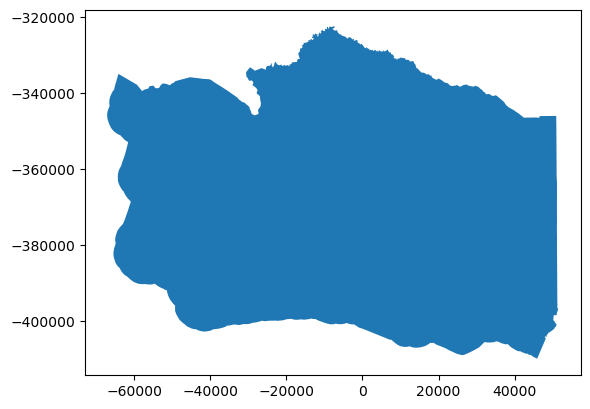

In [34]:
sb_shp = gpd.read_file('/capstone/wildfire_prep/data/ca_counties/sb_county_boundary.shp')
print(sb_shp.total_bounds)
print(sb_shp.crs)
box(*sb_shp.total_bounds)

sb_shp.plot()

In [ ]:
for geom in master_geometries[:100]:
    with rasterio.open(fp) as src:
        ndvi_layer = src.read(1)
        l_tif, b_tif, r_tif, t_tif = src.bounds
        l_sb, b_sb, r_sb, t_sb = sb_shp.total_bounds
        print([l_tif > l_sb, b_tif > b_sb, r_tif < r_sb, t_tif < t_sb])
        print(src.transform)
        plt.plot(*box(*src.bounds).exterior.xy)

[np.True_, np.True_, np.True_, np.True_]
| 3.00, 0.00,-27260.08|
| 0.00,-3.00,-392945.52|
| 0.00, 0.00, 1.00|
[np.True_, np.True_, np.True_, np.True_]
| 3.00, 0.00, 35053.82|
| 0.00,-3.00,-346832.73|
| 0.00, 0.00, 1.00|
[np.True_, np.True_, np.True_, np.True_]
| 3.00, 0.00,-20261.70|
| 0.00,-3.00,-343351.92|
| 0.00, 0.00, 1.00|
[np.True_, np.True_, np.True_, np.True_]
| 3.00, 0.00, 47632.49|
| 0.00,-3.00,-347825.78|
| 0.00, 0.00, 1.00|
[np.True_, np.True_, np.True_, np.True_]
| 3.00, 0.00,-12927.45|
| 0.00,-3.00,-322491.39|
| 0.00, 0.00, 1.00|
[np.True_, np.True_, np.True_, np.True_]
| 3.00, 0.00, 35053.82|
| 0.00,-3.00,-346832.73|
| 0.00, 0.00, 1.00|
[np.True_, np.True_, np.True_, np.True_]
| 3.00, 0.00,-9769.63|
| 0.00,-3.00,-377331.60|
| 0.00, 0.00, 1.00|
[np.True_, np.True_, np.True_, np.True_]
| 3.00, 0.00,-25406.82|
| 0.00,-3.00,-351942.82|
| 0.00, 0.00, 1.00|
[np.True_, np.True_, np.True_, np.True_]
| 3.00, 0.00,-49083.52|
| 0.00,-3.00,-374253.23|
| 0.00, 0.00, 1.00|
[np.True_, 

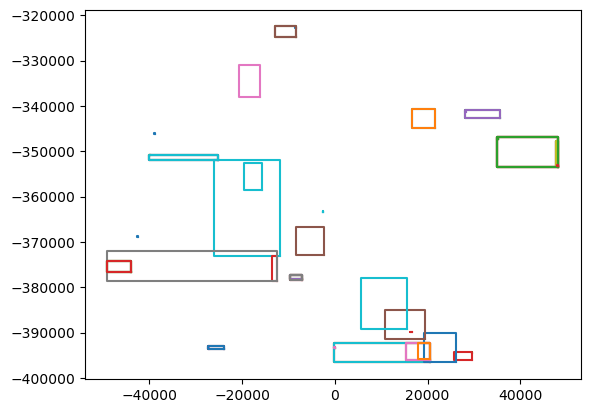

In [ ]:
for fp in reproj_ndvi_filepaths_2023_jan[:100]:
    with rasterio.open(fp) as src:
        ndvi_layer = src.read(1)
        l_tif, b_tif, r_tif, t_tif = src.bounds
        l_sb, b_sb, r_sb, t_sb = sb_shp.total_bounds
        print([l_tif > l_sb, b_tif > b_sb, r_tif < r_sb, t_tif < t_sb])
        print(src.transform)
        plt.plot(*box(*src.bounds).exterior.xy)

<Axes: >

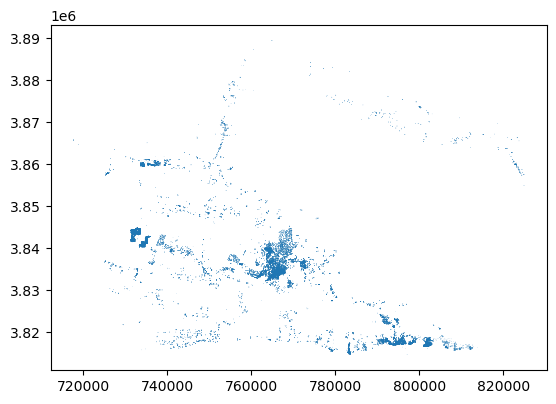

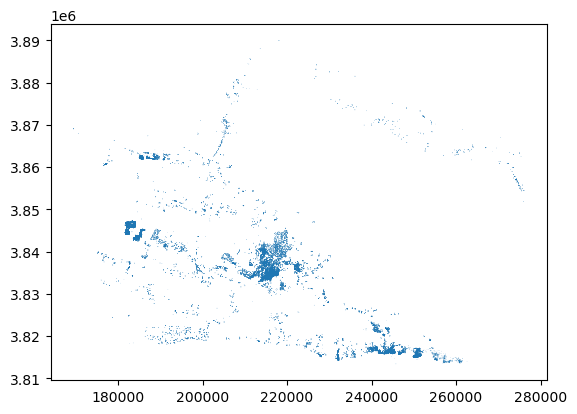

In [29]:
master_geometries_32610.plot()
master_geometries_32611.plot()

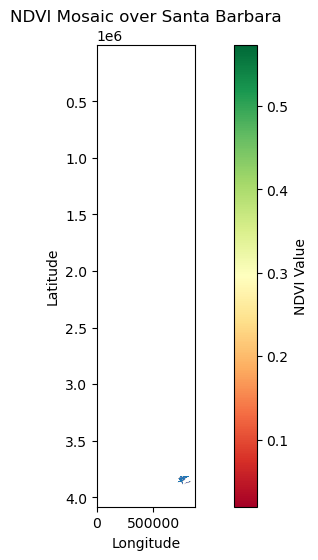

In [26]:
master_geometries_32611 = master_geometries.to_crs("EPSG:32611")
master_geometries_32610 = master_geometries.to_crs("EPSG:32610")

fig, ax = plt.subplots(figsize=(10, 6))  # Create a shared axis

for fp in ndvi_filepaths_2023_jan[:100]:
    with rasterio.open(fp) as src:


        ndvi_layer = src.read(1)  # Read NDVI data
        
        # print(f"Original bounds: {src.bounds}")  # Verify input bounds


        ndvi_reproj = ax.imshow(ndvi_layer.squeeze(), cmap="RdYlGn")  # Use `ax.imshow()`

# Ensure vector geometries are plotted on the same axis
master_geometries_32610.plot(ax=ax)

plt.colorbar(ndvi_reproj, ax=ax, label="NDVI Value")  # Ensure colorbar is linked to the correct axis
plt.title("NDVI Mosaic over Santa Barbara")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Original Transform: 
| 3.00, 0.00,-27260.08|
| 0.00,-3.00,-392945.52|
| 0.00, 0.00, 1.00|
Corrected Transform: 
| 8.99, 0.00,-27260.08|
| 0.00,-23.98,-392945.52|
| 0.00, 0.00, 1.00|
Original Transform: 
| 3.00, 0.00, 35053.82|
| 0.00,-3.00,-346832.73|
| 0.00, 0.00, 1.00|
Corrected Transform: 
| 8.99, 0.00, 35053.82|
| 0.00,-23.98,-346832.73|
| 0.00, 0.00, 1.00|
Original Transform: 
| 3.00, 0.00,-20261.70|
| 0.00,-3.00,-343351.92|
| 0.00, 0.00, 1.00|
Corrected Transform: 
| 9.00, 0.00,-20261.70|
| 0.00,-23.99,-343351.92|
| 0.00, 0.00, 1.00|
Original Transform: 
| 3.00, 0.00, 47632.49|
| 0.00,-3.00,-347825.78|
| 0.00, 0.00, 1.00|
Corrected Transform: 
| 9.00, 0.00, 47632.49|
| 0.00,-24.01,-347825.78|
| 0.00, 0.00, 1.00|
Original Transform: 
| 3.00, 0.00,-12927.45|
| 0.00,-3.00,-322491.39|
| 0.00, 0.00, 1.00|
Corrected Transform: 
| 8.99, 0.00,-12927.45|
| 0.00,-23.98,-322491.39|
| 0.00, 0.00, 1.00|
Original Transform: 
| 3.00, 0.00, 35053.82|
| 0.00,-3.00,-346832.73|
| 0.00, 0.00, 1.00|


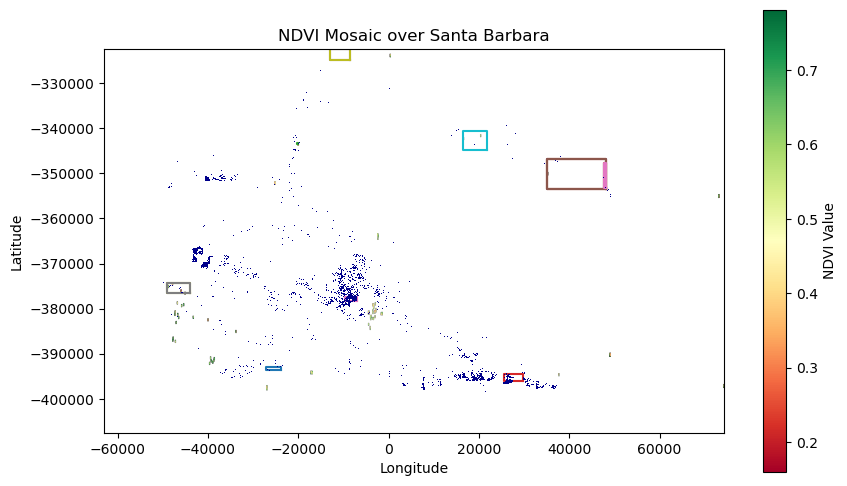

In [172]:
fig, ax = plt.subplots(figsize=(10, 6))  # Create a shared axis

# Ensure vector geometries are plotted on the same axis
# master_geometries.plot(ax=ax, linewidth=1, color="black")

for fp in reproj_ndvi_filepaths_2023_jan[:20]:
    with rasterio.open(fp) as src:

        plt.plot(*box(*src.bounds).exterior.xy)


        ndvi_layer = src.read(1)  # Read NDVI data

        expected_transform = Affine(
            src.transform[0] * 3, 0, src.transform[2],  # Adjust scale & top-left X
            0, src.transform[4] * 8, src.transform[5]   # Adjust scale & top-left Y
        )


        # Read NDVI layer but override transform
        ndvi_layer = src.read(1)
        corrected_meta = src.meta.copy()
        corrected_meta["transform"] = expected_transform

        print(f"Original Transform: \n{src.transform}")
        print(f"Corrected Transform: \n{expected_transform}")
        
        # print(ndvi_layer)

        # if np.all(ndvi_layer == 0):
        #     print(f"Skipping {fp} (NDVI layer contains only zeros)")
        #     continue


        ndvi_layer = np.ma.masked_where(ndvi_layer == 0, ndvi_layer)


        # print(f"Original bounds: {src.bounds}")  # Verify input bounds
        # print(f"geom bounds: {box(*src.bounds).exterior.xy}")
        # print(f"current transform: \n{src.transform[0:6]}")
        # print(f"transform target 1: {src.transform[0]}")
        # print(f"transform target 2: {src.transform[4]}")

        # src.transform[0] = src.transform[0] * 10
        # src.transform[4] = src.transform[4] * 10

        # print(f"transform target 1 after multiply: {src.transform[0]}")
        # print(f"transform target 2 after multiply: {src.transform[4]}")

        # plt.plot(*box(*src.bounds).exterior.xy)
        
        # ndvi_reproj = ax.imshow(ndvi_layer.squeeze(), cmap="RdYlGn", zorder = 1)  # Use `ax.imshow()`
        ndvi_reproj = ax.imshow(ndvi_layer, cmap="RdYlGn", extent=[
            expected_transform.c, 
            expected_transform.c + ndvi_layer.shape[1] * expected_transform.a,  # Right boundary
            expected_transform.f + ndvi_layer.shape[0] * expected_transform.e,  # Bottom boundary
            expected_transform.f  # Top boundary
        ])

# Ensure vector geometries are plotted on the same axis
master_geometries.plot(ax=ax, linewidth=1, color="darkblue", zorder = 2)

plt.colorbar(ndvi_reproj, ax=ax, label="NDVI Value")  # Ensure colorbar is linked to the correct axis
plt.title("NDVI Mosaic over Santa Barbara")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

CPLE_AppDefinedError: Too many points (441 out of 441) failed to transform, unable to compute output bounds.

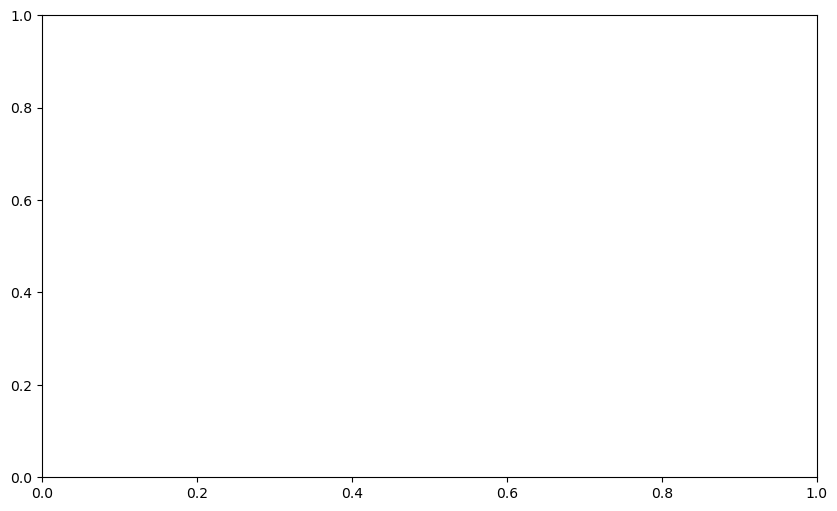

In [171]:
def reproject_ndvi(fps, intermediate_crs="EPSG:4326", final_crs="EPSG:3310"):

    fig, ax = plt.subplots(figsize=(10, 6))

    for fp in fps:
        with rasterio.open(fp) as src:
            # Step 1: Reproject from EPSG:32611 → EPSG:32610
            transform_32610, width_32610, height_32610 = calculate_default_transform(
                src.crs, intermediate_crs, src.width, src.height, *src.bounds
            )

            ndvi_32610 = np.empty((height_32610, width_32610), dtype=src.dtypes[0])
            reproject(
                source=src.read(1),
                destination=ndvi_32610,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform_32610,
                dst_crs=intermediate_crs,
                resampling=Resampling.bilinear
            )

            # Step 2: Reproject from EPSG:32610 → EPSG:3310
            transform_3310, width_3310, height_3310 = calculate_default_transform(
                intermediate_crs, final_crs, width_32610, height_32610, *src.bounds
            )

            ndvi_3310 = np.empty((height_3310, width_3310), dtype=src.dtypes[0])
            reproject(
                source=ndvi_32610,
                destination=ndvi_3310,
                src_transform=transform_32610,
                src_crs=intermediate_crs,
                dst_transform=transform_3310,
                dst_crs=final_crs,
                resampling=Resampling.bilinear
            )

            # Extract top-left coordinate for proper plotting
            expected_transform = Affine(
                transform_3310.a, transform_3310.b, transform_3310.c,
                transform_3310.d, transform_3310.e, transform_3310.f
            )

            # Plot results
            end = ax.imshow(ndvi_3310, cmap="RdYlGn", extent=[
                expected_transform.c,  # Left boundary
                expected_transform.c + width_3310 * expected_transform.a,  # Right boundary
                expected_transform.f + height_3310 * expected_transform.e,  # Bottom boundary
                expected_transform.f  # Top boundary
            ])

    plt.title(f"NDVI Raster Reprojected from EPSG:32611 → EPSG:32610 → EPSG:3310")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.colorbar(end, ax=ax, label="NDVI Value")
    plt.show()

# Example usage
reproject_ndvi(reproj_ndvi_filepaths_2023_jan[:10])




3310
3310
3310
3310
3310
3310
3310
3310
3310
3310


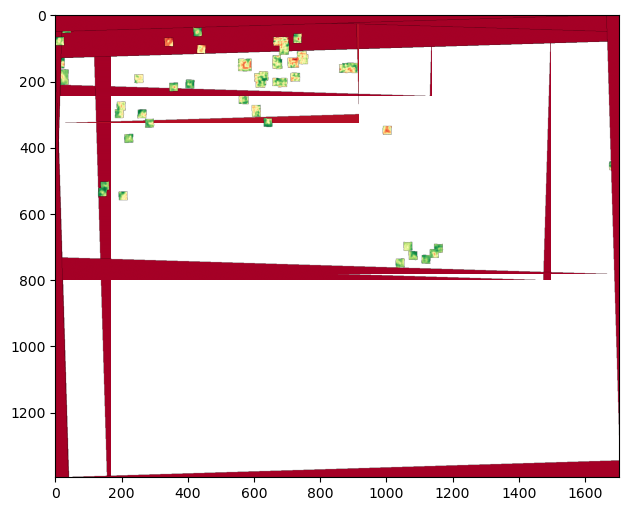

In [127]:
fig, ax = plt.subplots(figsize=(10, 6))

for fp in reproj_ndvi_filepaths_2023_jan[:10]:
    curr_crs = GeoTiff(fp, as_crs = None).crs_code
    geo_tiff = GeoTiff(fp, as_crs=curr_crs)
    ndvi_layer = geo_tiff.read()

    print(curr_crs)

    ndvi_reproj = ax.imshow(ndvi_layer, cmap="RdYlGn")  # Use `ax.imshow()`

# master_geometries.plot(ax=ax)

In [69]:
master_geometries.crs

<Projected CRS: EPSG:3310>
Name: NAD83 / California Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - California.
- bounds: (-124.45, 32.53, -114.12, 42.01)
Coordinate Operation:
- name: California Albers
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

bounds: BoundingBox(left=783348.0, bottom=3882087.0, right=783432.0, top=3882171.0)
bounds: BoundingBox(left=222717.0, bottom=3849093.0, right=222846.0, top=3849282.0)
bounds: BoundingBox(left=734175.0, bottom=3859566.0, right=748962.0, top=3860361.0)
bounds: BoundingBox(left=236034.0, bottom=3881502.0, right=236118.0, top=3881586.0)
bounds: BoundingBox(left=239871.0, bottom=3815946.0, right=244995.0, top=3819471.0)
bounds: BoundingBox(left=254106.0, bottom=3870081.0, right=254247.0, top=3870390.0)
bounds: BoundingBox(left=765324.0, bottom=3833877.0, right=768033.0, top=3834759.0)
bounds: BoundingBox(left=732108.0, bottom=3842256.0, right=732228.0, top=3842376.0)
bounds: BoundingBox(left=734175.0, bottom=3859566.0, right=748962.0, top=3860361.0)
bounds: BoundingBox(left=754938.0, bottom=3853257.0, right=758637.0, top=3859245.0)
bounds: BoundingBox(left=734175.0, bottom=3859566.0, right=748962.0, top=3860361.0)
bounds: BoundingBox(left=224325.0, bottom=3815946.0, right=244995.0, top=381

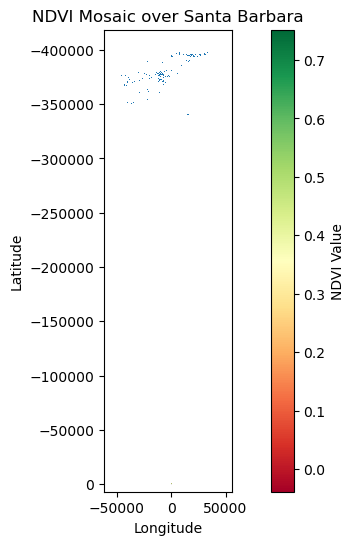

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))  # Create a shared axis

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3310", always_xy=True)

for fp in ndvi_filepaths_2023_jan[:20]:
    with rasterio.open(fp) as src:
        ndvi_layer = src.read(1)  # Read NDVI data
        
        print(f"initial bounds: {src.bounds}")  # Verify input bounds
        print(f"initial transform: \n{src.transform}")  # Verify input bounds

        x_min, y_max = transformer.transform(src.bounds.left, src.bounds.top)
        x_max, y_min = transformer.transform(src.bounds.right, src.bounds.bottom)


        transform, width, height = calculate_default_transform(
        src.crs, "EPSG:3310", src.width, src.height, x_min, y_max, x_max, y_min
        )


        kwargs = src.meta.copy()  # Copy existing metadata
        kwargs.update({
            'crs': target_crs_final,   # Update projection
            'transform': transform,    # Apply new transformation matrix
            'width': width,            # Adjust raster width
            'height': height           # Adjust raster height
        })



         # Create an empty array for the reprojected data
        with rasterio.open(final_path, "w", **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs="EPSG:3310",
                    resampling=Resampling.bilinear,
                )

        
        print(f"Reprojected bounds: {transform}")  # Check the new spatial reference

        ndvi_reproj = ax.imshow(ndvi_layer.squeeze(), cmap="RdYlGn")

# Ensure vector geometries are plotted on the same axis
master_geometries.plot(ax=ax)

plt.colorbar(ndvi_reproj, ax=ax, label="NDVI Value")  # Ensure colorbar is linked to the correct axis
plt.title("NDVI Mosaic over Santa Barbara")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Skipping /data/wildfire_prep/ndvi/2023/jan/wgs84/ndvi_123.tif (CRS is EPSG:32610)
Original bounds: BoundingBox(left=222717.0, bottom=3849093.0, right=222846.0, top=3849282.0)
Reprojected bounds: | 3.00, 0.00,-2645.01|
| 0.00,-3.00,-363155.88|
| 0.00, 0.00, 1.00|
Skipping /data/wildfire_prep/ndvi/2023/jan/wgs84/ndvi_165.tif (CRS is EPSG:32610)
Original bounds: BoundingBox(left=236034.0, bottom=3881502.0, right=236118.0, top=3881586.0)
Reprojected bounds: | 3.00, 0.00, 9681.83|
| 0.00,-3.00,-330460.81|
| 0.00, 0.00, 1.00|
Original bounds: BoundingBox(left=239871.0, bottom=3815946.0, right=244995.0, top=3819471.0)
Reprojected bounds: | 3.00, 0.00, 15371.49|
| 0.00,-3.00,-392294.71|
| 0.00, 0.00, 1.00|
Original bounds: BoundingBox(left=254106.0, bottom=3870081.0, right=254247.0, top=3870390.0)
Reprojected bounds: | 3.00, 0.00, 28060.88|
| 0.00,-3.00,-341109.52|
| 0.00, 0.00, 1.00|
Skipping /data/wildfire_prep/ndvi/2023/jan/wgs84/ndvi_152.tif (CRS is EPSG:32610)
Skipping /data/wildfire_prep

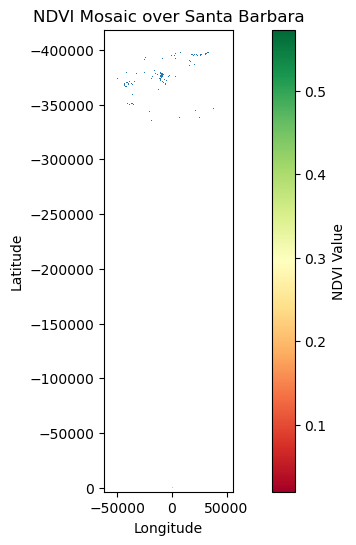

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))  # Create a shared axis

for fp in ndvi_filepaths_2023_jan[:100]:
    with rasterio.open(fp) as src:

        if src.crs != "EPSG:32611":
            print(f"Skipping {fp} (CRS is {src.crs})")
            continue


        ndvi_layer = src.read(1)  # Read NDVI data
        
        print(f"Original bounds: {src.bounds}")  # Verify input bounds
        
        # Calculate transformation parameters
        target_crs = "EPSG:3310"
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds
        )
        
        # Create an empty array for the reprojected data
        ndvi_reproj = np.empty((height, width), dtype=ndvi_layer.dtype)
        
        # Perform reprojection
        reproject(
            source=ndvi_layer,
            destination=ndvi_reproj,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=target_crs,
            resampling=Resampling.nearest
        )
        
        print(f"Reprojected bounds: {transform}")  # Check the new spatial reference


        ndvi_reproj = ax.imshow(ndvi_layer.squeeze(), cmap="RdYlGn")  # Use `ax.imshow()`

# Ensure vector geometries are plotted on the same axis
master_geometries.plot(ax=ax)

plt.colorbar(ndvi_reproj, ax=ax, label="NDVI Value")  # Ensure colorbar is linked to the correct axis
plt.title("NDVI Mosaic over Santa Barbara")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

<Axes: >

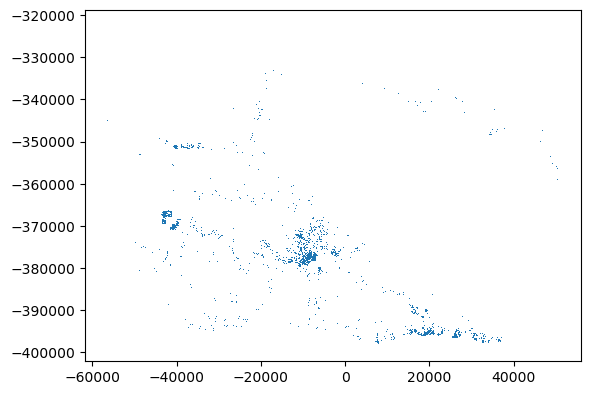

In [ ]:
master_geometries.plot()

In [72]:
response = input("Will overwrite tabulated NDVI .csv. Execute? (yes/no): ")
if response.lower() == "yes":

    # run ndvi statistics through each reprojected ndvi tif
    template_df = pd.DataFrame(columns=['inspection_id', 'mean', 'min', 'max', 'ndvi_year', 'ndvi_month'])


    for year in year_sea:
        for month_num, month in zip(reversed(range(1,13)), month_name):
            print(f'iteration for {year}/{month}')
            curr = (
                get_ndvi_value(
                    globals()[f'reproj_ndvi_filepaths_{year}_{month}'], 
                    master_geometries[
                        (master_geometries["year"] == int(year)) & 
                        (master_geometries["month"] == month_num)
                        ]
                    )
                    .assign(ndvi_year = year)
                    .assign(ndvi_month = month_num)
            )
            template_df = pd.concat([template_df, curr])

    template_df.to_csv('/capstone/wildfire_prep/data/ndvi_csv/ndvi_parcels_2.csv')

    print("NDVI parcel csv calculated and saved.")
else:
    print("Execution canceled.")

iteration for 2019/dec
length of original geometries: 300
total intersection polygons: 679
length of end dataset for this month/year: 22
------------------------------

iteration for 2019/nov


/tmp/ipykernel_2111477/3686868509.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  template_df = pd.concat([template_df, curr])


length of original geometries: 2533
total intersection polygons: 16916
length of end dataset for this month/year: 327
------------------------------

iteration for 2019/oct


KeyboardInterrupt: 